# ARCHS4 Correlated Genes → Perturb-Seqr Up/Down Regulators

This notebook demonstrates an end-to-end workflow:

1. **[ARCHS4](https://archs4.org/)** — a database of gene-level expression computed by uniformly
   processing hundreds of thousands of publicly available human and mouse RNA-seq samples. Its
   correlation endpoint computes the Pearson correlation between the log2-normalized expression
   of an input gene and every other gene across a background of samples, and returns the genes
   whose expression is most **positively** correlated (co-regulated / co-expressed) and most
   **negatively** correlated (anti-regulated) with it. Here we pull the top **100** genes in each
   direction (previously only the top 10 were used).
2. **[Perturb-Seqr](https://perturbseqr.maayanlab.cloud/)** — a connectivity-mapping search engine
   that aggregates drug and gene-perturbation signatures from many public datasets (LINCS L1000,
   CREEDS, RummaGEO, Perturb Atlas, SciPlex, DeepCover MoA, Tahoe-100M, and more). We use the
   positively-correlated genes as an "up" gene set and the negatively-correlated genes as a "down"
   gene set, and ask Perturb-Seqr which drugs and gene perturbations **mimic** (push genes in the
   same direction) or **reverse** (push genes in the opposite direction) this signature.

Along the way this notebook:
- Explains the statistical method behind each step
- Adds **table legends/captions** describing exactly what each table shows
- Adds **bar charts** visualizing the top hits at every stage
- Adds **download buttons/links** so every table can be saved as a CSV
- Links out to the live ARCHS4 gene page for further exploration

Feel free to change `EXAMPLE_GENE` below to any gene symbol of interest — this version uses
**`C9orf72`** (a gene strongly associated with ALS/FTD) as the example.

In [2]:
!pip install -q requests pandas matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML, FileLink

# ---- Configuration ----
EXAMPLE_GENE = "CDKN1A"   # change this to any gene symbol
SPECIES = "human"
META_TERM = ""  # tissue/cell-type/condition to restrict the sample background
                    # (the ARCHS4 correlation endpoint appears to require this —
                    #  omitting it causes a 500 error, likely because it tries to
                    #  correlate across the entire ~1M+ sample corpus). "brain" is
                    #  a broad, common GEO metadata keyword relevant to C9orf72
                    #  (implicated in ALS/FTD, both neurodegenerative diseases).
                    #  Narrower terms (e.g. "ALS", "motor neuron") may not match
                    #  enough samples and can trigger a 500 error from the endpoint --
                    #  if that happens, try a broader/more common keyword like
                    #  "brain", "liver", "PBMC", "HeLa", or "lung cancer".
TOP_N_CORR = 100    # how many top +/- correlated genes to use as the signature
                    # (previously this was limited to the top 10)

pd.set_option("display.max_colwidth", 120)

## Step 1: ARCHS4 — Gene Correlation Analysis

Query [ARCHS4's](https://archs4.org/) correlation endpoint (`/sigpy/data/correlation`) to get the
genes whose expression across samples is most positively and most negatively correlated with
`EXAMPLE_GENE`.

**Method:** ARCHS4 uniformly aligns and quantifies gene-level expression from public RNA-seq
submissions to GEO/SRA. For a given input gene, it computes the Pearson correlation coefficient
between that gene's log2-transformed expression and every other gene's expression, across the
sample background selected by `META_TERM` (or the full corpus if left blank). Genes are then
ranked by correlation coefficient: strongly **positive** values indicate genes that tend to be
co-expressed with the input gene (turned on/off together), while strongly **negative** values
indicate genes whose expression moves in the opposite direction. We request the top `TOP_N_CORR`
genes in each direction (`k=TOP_N_CORR` in the request payload) rather than relying on the
endpoint's default page size.

See the [ARCHS4 documentation](https://maayanlab.cloud/archs4/help.html) for more detail on how
the expression matrices and correlations are computed.

In [4]:
def _archs4_correlation_request(gene, species, meta, k):
    """Single raw POST to the ARCHS4 correlation endpoint. Returns (ok, response)."""
    url = "https://maayanlab.cloud/sigpy/data/correlation"
    payload = {"gene": gene, "species": species, "meta": meta, "k": k}
    response = requests.post(url, json=payload)
    return response.ok, response


def get_archs4_correlation(gene: str, species: str = "human", meta: str = None, k: int = 100):
    """Fetch top positively/negatively correlated genes for `gene` from ARCHS4.

    `meta` restricts the sample background used to compute correlation (e.g. a
    tissue, cell line, or disease keyword); omitting it correlates across ARCHS4's
    entire ~1M+ sample corpus. `k` controls how many top positively/negatively
    correlated genes are returned.

    The live endpoint can return a 500 error for a few different reasons and
    unfortunately doesn't distinguish between them in its response body. To make
    the notebook resilient, this function retries with progressively simpler
    parameters -- and, importantly, also retries with the gene symbol upper-cased.
    ARCHS4's gene table appears to be keyed on upper-case symbols internally, so a
    mixed-case official HGNC/MGI symbol (e.g. "C9orf72") can 500 even though the
    correlation logic itself works fine once the symbol matches (this is easy to
    miss when testing only with genes that are already all-caps, like "TP53").

    Prints a note each time it falls back, so you can see which combination
    actually worked -- or, if every combination fails, see every server response.
    """
    gene_variants = [gene]
    if gene.upper() not in gene_variants:
        gene_variants.append(gene.upper())

    param_variants = [
        {"meta": meta, "k": k},
        {"meta": meta, "k": None},
        {"meta": None, "k": k},
        {"meta": None, "k": None},
    ]
    # de-duplicate consecutive identical param combos (e.g. if meta is already None)
    deduped_params = []
    for p in param_variants:
        if not deduped_params or deduped_params[-1] != p:
            deduped_params.append(p)

    attempts = [
        {"gene": g, **p} for g in gene_variants for p in deduped_params
    ]

    last_response = None
    for i, attempt in enumerate(attempts):
        ok, response = _archs4_correlation_request(
            attempt["gene"], species, attempt["meta"], attempt["k"]
        )
        last_response = response
        if ok:
            if attempt["gene"] != gene:
                print(f"Note: '{gene}' did not resolve, but upper-cased '{attempt['gene']}' did.")
            if i > 0:
                print(f"Note: succeeded with gene={attempt['gene']!r}, meta={attempt['meta']!r}, k={attempt['k']!r}.")
            return response.json()
        print(
            f"Attempt {i + 1}/{len(attempts)} failed "
            f"(gene={attempt['gene']!r}, meta={attempt['meta']!r}, k={attempt['k']!r}): "
            f"{response.status_code} {response.reason}"
        )

    raise RuntimeError(
        f"ARCHS4 correlation request failed for gene={gene!r} after trying gene-casing "
        f"and meta/k fallbacks. Last response ({last_response.status_code}):\n"
        f"{last_response.text[:2000]}\n\n"
        "This usually means either: (1) the gene symbol (in any casing) isn't recognized "
        "by ARCHS4 for this species -- double-check the official HGNC/MGI symbol, or (2) "
        "the `meta` keyword doesn't match enough GEO samples -- try a broader/more common "
        "one (e.g. 'brain', 'liver', 'PBMC', 'HeLa', 'lung cancer')."
    )


corr_result = get_archs4_correlation(EXAMPLE_GENE, species=SPECIES, meta=META_TERM, k=TOP_N_CORR)

df_pos = pd.DataFrame(corr_result.get("positive_correlated_genes", []))
df_neg = pd.DataFrame(corr_result.get("negative_correlated_genes", []))

print(f"Positively correlated genes with {EXAMPLE_GENE}: {len(df_pos)}")
print(f"Negatively correlated genes with {EXAMPLE_GENE}: {len(df_neg)}")

display(HTML(f"<b>Table 1. Top {min(TOP_N_CORR, len(df_pos))} genes positively correlated with {EXAMPLE_GENE}</b>"))
df_pos.head(TOP_N_CORR)

Positively correlated genes with CDKN1A: 100
Negatively correlated genes with CDKN1A: 100


,correlation,gene,mean_log_expression
0,0.594321,RHOC,6.796622
1,0.544162,GRN,8.064105
2,0.542799,EHD4,5.742396
3,0.540968,RPN1,8.804778
4,0.533271,ELOVL1,5.872771
...,...,...,...
95,0.447874,PEA15,7.202587
96,0.447449,TMEM259,6.909568
97,0.447401,SPSB1,3.932706
98,0.447048,CNPPD1,6.058038


**Table 1 legend.** The `TOP_N_CORR` genes whose expression across the ARCHS4 sample background
is most **positively** correlated with `EXAMPLE_GENE`. `correlation` is the Pearson correlation
coefficient (−1 to 1); `mean_log_expression` is the gene's mean log2-transformed expression across
the same sample background. Sorted by descending correlation.

In [5]:
display(HTML(f"<b>Table 2. Top {min(TOP_N_CORR, len(df_neg))} genes negatively correlated with {EXAMPLE_GENE}</b>"))
df_neg.head(TOP_N_CORR)

,correlation,gene,mean_log_expression
0,-0.451521,USP12P2,1.131004
1,-0.450953,CCNL2P1,1.383986
2,-0.448426,OSTCP8,1.322672
3,-0.445280,ENSG00000255084,1.419408
4,-0.437202,LNCPRESS2,1.066431
...,...,...,...
95,-0.404607,ENSG00000239465,1.491054
96,-0.404348,ENSG00000260171,1.031230
97,-0.404186,ENSG00000226410,1.014852
98,-0.404177,ENSG00000278109,1.574488


**Table 2 legend.** The `TOP_N_CORR` genes whose expression is most **negatively** correlated
(anti-correlated) with `EXAMPLE_GENE` — as one gene's expression rises, these tend to fall, and
vice versa. Same columns as Table 1, sorted by ascending (most negative) correlation.

### Bar chart: top correlated genes

A quick visual of the strongest positive and negative correlations, so the magnitude of the
signal is easy to compare at a glance.

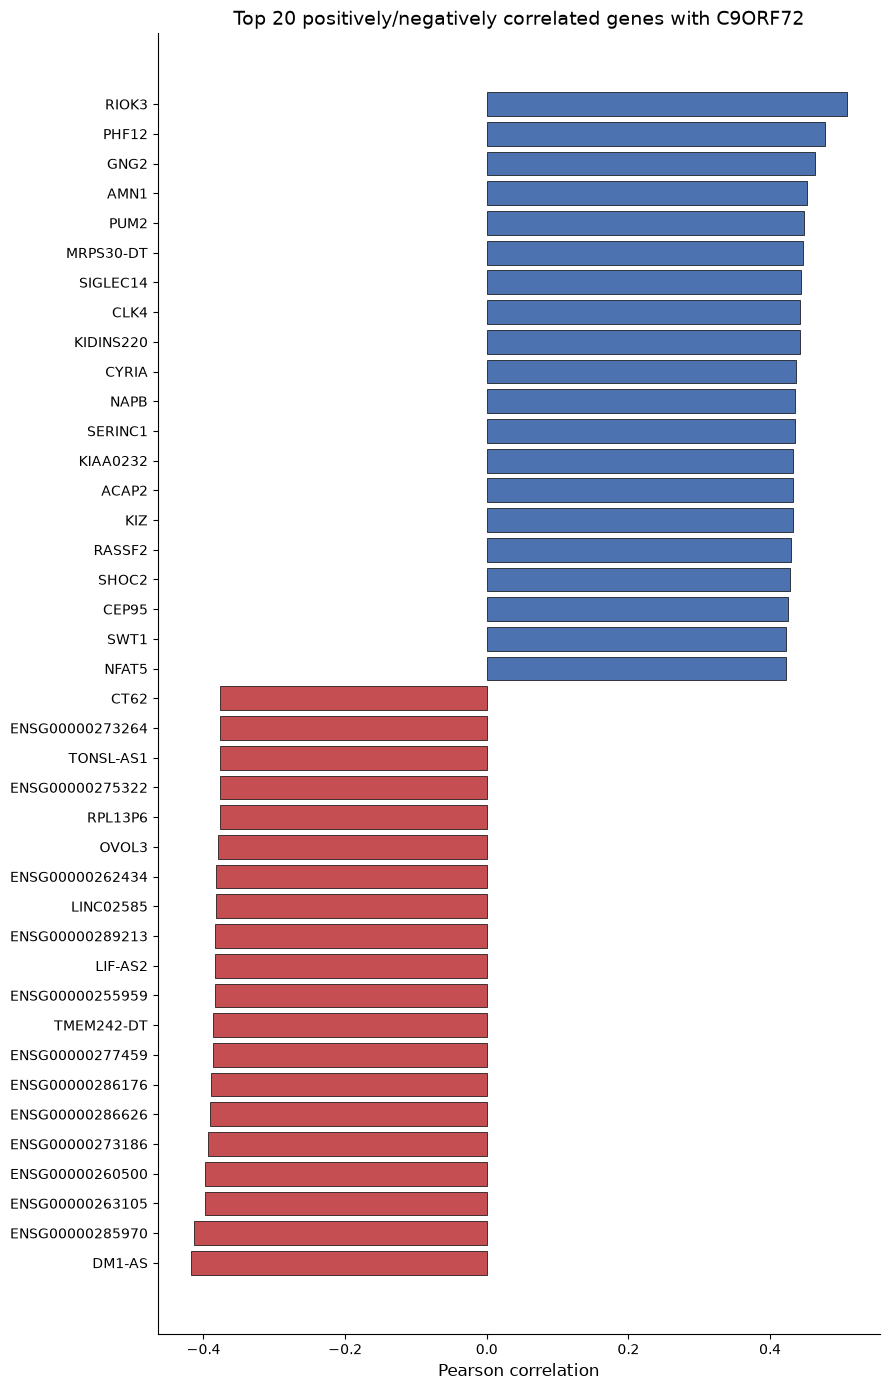

In [7]:
def make_bar_chart(labels, scores, title, xlabel, colors="lightskyblue", figsize=None):
    """Horizontal bar chart, highest score at the top."""
    labels = list(labels)
    scores = list(scores)
    if figsize is None:
        figsize = (9, max(3, 0.35 * len(labels)))
    order = np.argsort(scores)  # ascending so the highest score plots at the top
    labels_sorted = [labels[i] for i in order]
    scores_sorted = [scores[i] for i in order]
    if isinstance(colors, (list, tuple, np.ndarray)):
        colors_sorted = [colors[i] for i in order]
    else:
        colors_sorted = colors

    plt.figure(figsize=figsize)
    ax = plt.gca()
    ax.barh(labels_sorted, scores_sorted, color=colors_sorted, edgecolor="black", linewidth=0.5)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    plt.tight_layout()
    return ax


chart_n = min(20, len(df_pos), len(df_neg))
chart_genes = pd.concat([
    df_pos.head(chart_n).assign(direction="positive"),
    df_neg.head(chart_n).assign(direction="negative"),
], ignore_index=True)
bar_colors = ["#4C72B0" if d == "positive" else "#C44E52" for d in chart_genes["direction"]]

make_bar_chart(
    chart_genes["gene"], chart_genes["correlation"],
    title=f"Top {chart_n} positively/negatively correlated genes with {EXAMPLE_GENE}",
    xlabel="Pearson correlation", colors=bar_colors,
)
plt.savefig("archs4_correlated_genes_bar.png", bbox_inches="tight")
plt.show()

**Figure 1.** Top 20 positively (blue) and negatively (red) correlated genes with
`EXAMPLE_GENE`, ranked by Pearson correlation coefficient.

### Link to ARCHS4

Open the live ARCHS4 gene page to explore expression, correlation, and tissue/cell-type
enrichment for `EXAMPLE_GENE` interactively.

In [8]:
archs4_link = f"https://archs4.org/gene/{EXAMPLE_GENE}"
display(HTML(
    f"<div style='font-size:1.1rem; padding:0.5rem 0;'>"
    f"<a href='{archs4_link}' target='_blank'>Explore <b>{EXAMPLE_GENE}</b> on ARCHS4</a>"
    f"</div>"
    f"<div style='font-size:0.85rem; color:#777;'>Direct URL: <code>{archs4_link}</code></div>"
))

## Step 2: Build the up/down gene signature

Take the top `TOP_N_CORR` (100) positively-correlated genes as the **up** set and the top
`TOP_N_CORR` (100) negatively-correlated genes as the **down** set. These will be used as the
query signature for Perturb-Seqr.

In [9]:
genes_up = df_pos.sort_values("correlation", ascending=False)["gene"].head(TOP_N_CORR).tolist()
genes_down = df_neg.sort_values("correlation", ascending=True)["gene"].head(TOP_N_CORR).tolist()

print(f"Up genes ({len(genes_up)}):\n{genes_up}\n")
print(f"Down genes ({len(genes_down)}):\n{genes_down}")

Up genes (100):
['RIOK3', 'PHF12', 'GNG2', 'AMN1', 'PUM2', 'MRPS30-DT', 'SIGLEC14', 'CLK4', 'KIDINS220', 'CYRIA', 'NAPB', 'SERINC1', 'KIAA0232', 'ACAP2', 'KIZ', 'RASSF2', 'SHOC2', 'CEP95', 'SWT1', 'NFAT5', 'ENSG00000241860', 'JMJD1C', 'CCDC82', 'BAIAP2-DT', 'CEP68', 'RGS2', 'CBL', 'KPNA5', 'FGF13', 'MYSM1', 'RUFY2', 'AGO4', 'ZC3H12B', 'ZNF117', 'OSER1-DT', 'WTAP', 'NCOA1', 'PLXNC1', 'MCTP2', 'CEP170', 'TBCK', 'RABGAP1L', 'EZH1', 'FBXL5', 'ENSG00000288075', 'BLZF1', 'C21ORF62-AS1', 'RALGAPA1', 'CD46', 'FBXL4', 'INPP5B', 'MX2', 'ZNF182', 'USPL1', 'DMTF1', 'SNX30', 'ZFYVE16', 'ATP6V1A', 'CCDC39', 'DCP2', 'CRLF3', 'ARID4A', 'DICER1-AS1', 'BLOC1S6', 'ZNF445', 'ZNF81', 'TRAF6', 'INO80D', 'ZNF652', 'BSDC1', 'PJA2', 'PDS5B', 'ENSG00000289353', 'CNKSR2', 'RTN1', 'CLDND1', 'GBP4', 'LINC02193', 'KIAA0513', 'SESN3', 'PARP8', 'CEP97', 'IRAK3', 'BRWD1', 'TCP11L2', 'KIAA1109', 'SCAPER', 'HERC1', 'DNAJC16', 'ZNF586', 'FGD4', 'STARD3NL', 'SUSD6', 'PHF21A', 'FAR1', 'SPG11', 'GDI1', 'POLK', 'TRNT1', 'FPR

## Step 3: Perturb-Seqr — Paired Up/Down Gene Set Enrichment

Search the [Perturb-Seqr](https://perturbseqr.maayanlab.cloud/) Connectivity Map database for
drug and gene perturbations whose signatures **mimic** (same direction) or **reverse** (opposite
direction) the ARCHS4-derived up/down signature.

**Method:** Perturb-Seqr stores, for each perturbation experiment in its underlying datasets
(LINCS L1000, CREEDS, RummaGEO, Perturb Atlas, SciPlex, DeepCover MoA, Tahoe-100M, and others),
the set of genes that experiment pushed up and the set it pushed down. Given our `genes_up` and
`genes_down` query sets, Perturb-Seqr runs a paired Fisher's exact test against every stored
perturbation: a **mimicker** is a perturbation whose own up/down gene sets overlap our
`genes_up`/`genes_down` sets in the *same* direction (low `pvalueMimic`), while a **reverser**
overlaps them in the *opposite* direction (low `pvalueReverse`) — i.e. it could push expression
back toward baseline. Results are returned per-dataset (`nodes`) and as a **consensus** view that
aggregates evidence for the same perturbation across every dataset it appears in.

In [10]:
PERTURBSEQR_URL = "https://perturbseqr.maayanlab.cloud/graphql"


def parse_perturbation_term(term):
    """
    Perturb-Seqr packs the perturbation name together with metadata (cell line, tissue,
    dose, KO/KD/Mut label, dataset ID, gene set size, etc.) in the 'term' string, separated
    by '::'. The perturbation name is always the first '::'-delimited field; everything
    after is metadata. The direction ('up'/'down'), when present, is the last
    whitespace-separated token of the *last* '::' field.

    Examples:
        >>> parse_perturbation_term("TP53::CAL51::::::::KO::::SRP287851::2996 down")
        ('TP53', 'down')
        >>> parse_perturbation_term("glucagon::::::::::human::GSE171352::2::3 down")
        ('glucagon', 'down')
        >>> parse_perturbation_term("doxorubicin::::human dermal fibroblast::24h::0.3uM")
        ('doxorubicin', None)
    """
    fields = term.split("::")
    perturbation = fields[0].strip()
    last_field = fields[-1].strip() if fields else ""
    tokens = last_field.split(" ")
    direction = tokens[-1].lower() if len(tokens) > 1 and tokens[-1].lower() in ("up", "down") else None
    return perturbation, direction


def enrich_perturbseqr_up_down(genes_up: list, genes_down: list, first: int = 100, sort_by: str = "pvalue_mimic"):
    """Paired up/down gene set enrichment against Perturb-Seqr (exact schema from the skill docs).

    `first` controls how many raw per-dataset enrichment results are pulled in *before*
    Perturb-Seqr aggregates them into the `consensus` view -- it is not just a page size.
    Raising it changes which datasets' evidence feeds each perturbation's consensus
    p-value/odds-ratio, which can shift the consensus numbers and make them stop matching
    the website. Keep `first` at 100 (matching the website's own default) unless you have a
    specific reason to change it, and re-validate against the website if you do.

    IMPORTANT: `sort_by` isn't just cosmetic. The server only returns the top `first`
    per-dataset `nodes` ranked by `sort_by` -- entries that would rank well by the
    *other* metric but poorly by `sort_by` are never returned at all, not just sorted
    later in the list. Concretely: if you only ever call this with sort_by="pvalue_mimic"
    and then locally re-sort the same response by pvalueReverse to build a "top
    reversers" table, that table will be silently missing true top reversers that
    didn't also rank in the top `first` mimickers. To get correct top-N tables for
    *both* directions, call this function twice -- once with sort_by="pvalue_mimic"
    for the mimicker tables, and once with sort_by="pvalue_reverse" for the reverser
    tables -- and build each direction's tables only from its own matching call.
    """
    query = {
        "operationName": "PairEnrichmentQuery",
        "variables": {
            "filterTerm": "",
            "offset": 0,
            "first": first,
            "filterFda": False,
            "sortBy": sort_by,
            "filterKo": False,
            "topN": 1000,
            "pvalueLe": 0.05,
            "genesUp": genes_up,
            "genesDown": genes_down,
        },
        "query": """query PairEnrichmentQuery($genesUp: [String]!, $genesDown: [String]!, $filterTerm: String = \"\", $offset: Int = 0, $first: Int = 10, $filterFda: Boolean = false, $sortBy: String = \"\", $filterKo: Boolean = false, $topN: Int = 10000, $pvalueLe: Float = 0.05) {
  currentBackground {
    pairedEnrich(
      filterTerm: $filterTerm
      offset: $offset
      first: $first
      filterFda: $filterFda
      sortby: $sortBy
      filterKo: $filterKo
      topN: $topN
      pvalueLe: $pvalueLe
      genesDown: $genesDown
      genesUp: $genesUp
      ) {
        totalCount
        consensusCount
        consensus {
          drug
          oddsRatio
          pvalue
          adjPvalue
          approved
          countSignificant
          countInsignificant
          countUpSignificant
          pvalueUp
          adjPvalueUp
          oddsRatioUp
          pvalueDown
          adjPvalueDown
          oddsRatioDown
          libraries
          }
          nodes {
            adjPvalueMimic
            adjPvalueReverse
            mimickerOverlap
            oddsRatioMimic
            oddsRatioReverse
            pvalueMimic
            pvalueReverse
            reverserOverlap
            geneSet {
              nodes {
                id
                nGeneIds
                term
                geneSetFdaCountsById {
                  nodes {
                    count
                    approved
                    }
                  }
                library {
                  name
                  }
                }
              }
            }
          }
        }
      }
""",
    }

    response = requests.post(PERTURBSEQR_URL, json=query)
    if not response.ok:
        print(f"Perturb-Seqr request failed ({response.status_code}). Response body:")
        print(response.text[:2000])
    response.raise_for_status()
    res = response.json()

    consensus = res["data"]["currentBackground"]["pairedEnrich"]["consensus"]
    enrichment = res["data"]["currentBackground"]["pairedEnrich"]["nodes"]

    df_consensus_pair = pd.DataFrame(consensus).rename(
        columns={
            "drug": "perturbation",
            "pvalueUp": "pvalueMimic",
            "pvalueDown": "pvalueReverse",
            "adjPvalueUp": "adjPvalueMimic",
            "adjPvalueDown": "adjPvalueReverse",
            "oddsRatioUp": "oddsRatioMimic",
            "oddsRatioDown": "oddsRatioReverse",
        }
    )

    if not enrichment:
        return pd.DataFrame(), df_consensus_pair

    df_enrichment_pair = pd.DataFrame(enrichment)
    df_enrichment_pair["term"] = df_enrichment_pair["geneSet"].map(lambda t: parse_perturbation_term(t["nodes"][0]["term"])[0])
    df_enrichment_pair["approved"] = df_enrichment_pair["geneSet"].map(
        lambda t: t["nodes"][0]["geneSetFdaCountsById"]["nodes"][0]["approved"]
        if t["nodes"][0]["geneSetFdaCountsById"]["nodes"]
        else False
    )
    df_enrichment_pair["count"] = df_enrichment_pair["geneSet"].map(
        lambda t: t["nodes"][0]["geneSetFdaCountsById"]["nodes"][0]["count"]
        if t["nodes"][0]["geneSetFdaCountsById"]["nodes"]
        else 0
    )
    df_enrichment_pair["library"] = df_enrichment_pair["geneSet"].map(lambda t: t["nodes"][0]["library"]["name"])
    df_enrichment_pair["geneSetIdUp"] = df_enrichment_pair["geneSet"].map(
        lambda t: next((node["id"] for node in t["nodes"] if " up" in node["term"]), None)
    )
    df_enrichment_pair["geneSetIdDown"] = df_enrichment_pair["geneSet"].map(
        lambda t: next((node["id"] for node in t["nodes"] if " down" in node["term"]), None)
    )
    # nGeneIds legitimately differs between the up-side and down-side gene set of a pair, so
    # (unlike just reusing nodes[0] for both) pair each size to its matching up/down entry.
    df_enrichment_pair["nGeneIdsUp"] = df_enrichment_pair["geneSet"].map(
        lambda t: next((node["nGeneIds"] for node in t["nodes"] if " up" in node["term"]), None)
    )
    df_enrichment_pair["nGeneIdsDown"] = df_enrichment_pair["geneSet"].map(
        lambda t: next((node["nGeneIds"] for node in t["nodes"] if " down" in node["term"]), None)
    )

    df_enrichment_pair = df_enrichment_pair.drop(columns=["geneSet"])

    return df_enrichment_pair, df_consensus_pair


# Fetch twice -- once sorted/limited by mimic p-value, once by reverse p-value -- so the
# top-N per-dataset tables for each direction are both complete (see the note above).
df_enrichment_mimic, df_consensus_mimic = enrich_perturbseqr_up_down(genes_up, genes_down, sort_by="pvalue_mimic")
df_enrichment_reverse, df_consensus_reverse = enrich_perturbseqr_up_down(genes_up, genes_down, sort_by="pvalue_reverse")

print(f"[mimic-sorted]   {len(df_enrichment_mimic)} individual gene-set matches, {len(df_consensus_mimic)} consensus perturbations")
print(f"[reverse-sorted] {len(df_enrichment_reverse)} individual gene-set matches, {len(df_consensus_reverse)} consensus perturbations")

[mimic-sorted]   41 individual gene-set matches, 34 consensus perturbations
[reverse-sorted] 41 individual gene-set matches, 34 consensus perturbations


### Classifying hits as drug vs. gene perturbations

Perturb-Seqr's results mix **drug/chemical** perturbations (e.g. RummaGEO Chem, LINCS L1000
Chemical Perturbations, SciPlex, DeepCover MoA, Tahoe-100M, CREEDS Chem) and **gene**
perturbations (e.g. Replogle et al. Perturb-seq, Perturb Atlas, RummaGEO Gene, CREEDS Gene,
CM4AI) in the same result set, and `filterKo` isn't a reliable way to separate them. We classify
every hit here — for **both** the consensus table and the per-dataset table below — by keyword-
matching its source `library` name, and use that classification to split every downstream table
into "genes only" / "drugs only" views.

**Why this matters for comparing against the website:** the Perturb-Seqr website shows results in
separate tabs by type (drugs vs. genes), while a table built from the raw API response mixes both
types together, sorted purely by p-value. If you compare our combined table directly to a single
website tab, entries of the *other* type will look like unexplained "extras" — they aren't wrong,
they're just the other category. Use the type-specific tables below (or filter on the `type` /
`perturbation_type` column yourself) to match a specific website tab exactly.

In [11]:
# Keyword lists are matched as case-insensitive substrings against the `library` name Perturb-Seqr
# returns for each hit. Keep these in sync with any new datasets Perturb-Seqr adds -- the
# "unmatched libraries" diagnostic below will flag anything not covered so the lists can be
# extended.
DRUG_KEYWORDS = [
    "l1000 chemical",        # LINCS L1000 Chemical Perturbations (L2S2)
    "l1000 cp",               # LINCS L1000 Chemical Perturbations (alt. naming)
    "tahoe-100m",             # Tahoe-100M (Hugging Face)
    "nibr drug-seq",          # NIBR DRUG-seq U2OS MoABox Dataset (Harmonizome)
    "cmap build 02",          # Microarrays CMAP Build 02 (Harmonizome)
    "ginkgo bioworks",        # Ginkgo Bioworks (Hugging Face)
    "sciplex",                # SciPlex Drug Perturbations (Harmonizome)
    "deepcover moa",          # DeepCover MoA (Harmonizome)
    "creeds drug",            # CREEDS Drug Perturbations (CREEDS)
    "creeds chem",            # CREEDS Chemical Perturbations (alt. naming)
    "rummageo chem",          # RummaGEO Chemical Perturbations (the live API returns "RummaGEO Chem")
    "rummageo drug",          # RummaGEO Drug Perturbations (alt. naming, per Harmonizome docs)
]

GENE_KEYWORDS = [
    "perturb atlas",          # Perturb Atlas Human/Mouse Gene Perturbations (Harmonizome)
    "replogle",               # Replogle Perturb-seq K562/RPE1 (the live API returns "Replogle et al.")
    "l1000 gene knockouts",   # LINCS L1000 Gene Knockouts (L2S2)
    "l1000 xpr",              # LINCS L1000 CRISPR knockouts (alt. naming)
    "creeds gene",            # CREEDS Gene Perturbations (CREEDS)
    "cm4ai",                  # Bridge2AI CM4AI (Perturb-seq)
    "rummageo gene",          # RummaGEO Gene Perturbations (the live API returns "RummaGEO Gene")
]


def classify_libraries(libs):
    libs = [str(l).strip().lower() for l in (libs or [])]
    is_drug = any(any(kw in lib for kw in DRUG_KEYWORDS) for lib in libs)
    is_gene = any(any(kw in lib for kw in GENE_KEYWORDS) for lib in libs)
    if is_drug and is_gene:
        return "drug+gene"
    if is_drug:
        return "drug"
    if is_gene:
        return "gene"
    return "unknown"


# Apply to all four fetches (mimic-sorted and reverse-sorted, consensus and per-dataset).
for _df in (df_consensus_mimic, df_consensus_reverse):
    if not _df.empty:
        _df["perturbation_type"] = _df["libraries"].map(classify_libraries)

for _df in (df_enrichment_mimic, df_enrichment_reverse):
    if not _df.empty:
        _df["type"] = _df["library"].map(lambda lib: classify_libraries([lib]))

# Diagnostic: flag any library name not covered by either keyword list, across all four
# results, so DRUG_KEYWORDS/GENE_KEYWORDS can be extended if Perturb-Seqr returns something
# new/renamed.
all_libs = set()
for _df in (df_enrichment_mimic, df_enrichment_reverse):
    if not _df.empty:
        all_libs |= set(_df["library"].dropna().unique())
for _df in (df_consensus_mimic, df_consensus_reverse):
    if not _df.empty:
        all_libs |= {lib for libs in _df["libraries"] for lib in (libs or [])}

unmatched = sorted(lib for lib in all_libs if classify_libraries([lib]) == "unknown")
if unmatched:
    print("Library names not matched by either keyword list (extend DRUG_KEYWORDS/GENE_KEYWORDS):")
    for lib in unmatched:
        print(f"  - {lib}")
else:
    print("All returned library names were successfully classified as drug or gene.")

All returned library names were successfully classified as drug or gene.


### Mimickers vs. Reversers

- **Mimickers**: perturbations whose expression changes go in the *same* direction as our ARCHS4
  signature (low `pvalueMimic`).
- **Reversers**: perturbations whose expression changes go in the *opposite* direction (low
  `pvalueReverse`) — potentially candidate compounds/genes that could counteract the signature.

Below we split the **consensus** results (robust perturbations aggregated across every dataset
they appear in — one row per drug/gene) into top mimickers and top reversers, drawn from two
*separate* API calls — one sorted by `pvalueMimic`, one sorted by `pvalueReverse` (see the note
in the query function above for why a single call isn't enough to get both directions right).

**Important:** the Perturb-Seqr website's default results table shows **individual per-dataset
enrichment** rows, not consensus — that's why the same perturbation can appear more than once
there (once per dataset/library it's found in). If you're comparing against the website, use the
`df_enrichment_mimic` / `df_enrichment_reverse` (per-dataset) views further down instead of the
consensus tables here, and make sure the up/down gene lists you typed into the website match
`genes_up`/`genes_down` from this notebook exactly — a different input signature will always
produce different perturbations, regardless of whether the code is correct.

In [12]:
if not df_consensus_mimic.empty:
    top_mimickers = df_consensus_mimic.sort_values("pvalueMimic").head(20)
else:
    top_mimickers = pd.DataFrame()

if not df_consensus_reverse.empty:
    top_reversers = df_consensus_reverse.sort_values("pvalueReverse").head(20)
else:
    top_reversers = pd.DataFrame()

display(HTML("<b>Table 3. Top 20 mimicking perturbations (consensus, same-direction regulators)</b>"))
top_mimickers[["perturbation", "pvalueMimic", "adjPvalueMimic", "oddsRatioMimic", "libraries"]]

,perturbation,pvalueMimic,adjPvalueMimic,oddsRatioMimic,libraries
0,setdb1,1,1,0,[RummaGEO Gene]
31,aire,1,1,0,[RummaGEO Gene]
30,gcgr,1,1,0,[RummaGEO Gene]
29,FAM136A,1,1,0,[Replogle et al.]
28,folic acid,1,1,0,[RummaGEO Chem]
27,MED19,1,1,0,[Replogle et al.]
26,tamoxifen,1,1,0,[RummaGEO Chem]
25,znf165,1,1,0,[RummaGEO Gene]
24,STAT6,1,1,0,[Replogle et al.]
23,clarithromycin,1,1,0,[RummaGEO Chem]


**Table 3 legend.** Consensus perturbations (drugs or gene knockouts/knockdowns) whose aggregated
effect across all datasets they appear in most significantly **mimics** (pushes genes in the same
direction as) our `EXAMPLE_GENE` correlation signature, ranked by ascending `pvalueMimic`.

**Table 3b legend.** Same top 10 consensus mimicking perturbations as the top of Table 3, with an
added `neg_log10_pvalueMimic` column (`-log10(pvalueMimic)`) so statistical significance can be
compared at a glance — larger values are more significant.

In [14]:
display(HTML("<b>Table 4. Top 20 reversing perturbations (consensus, opposite-direction regulators)</b>"))
top_reversers[["perturbation", "pvalueReverse", "adjPvalueReverse", "oddsRatioReverse", "libraries"]]

,perturbation,pvalueReverse,adjPvalueReverse,oddsRatioReverse,libraries
0,aire,1,1,0,[RummaGEO Gene]
31,GATA1,1,1,0,[Replogle et al.]
30,MED27,1,1,0,[Replogle et al.]
29,otub1,1,1,0,[RummaGEO Gene]
28,gcgr,1,1,0,[RummaGEO Gene]
27,STAT6,1,1,0,[Replogle et al.]
26,MED17,1,1,0,[Replogle et al.]
25,znf165,1,1,0,[RummaGEO Gene]
24,folic acid,1,1,0,[RummaGEO Chem]
23,tamoxifen,1,1,0,[RummaGEO Chem]


**Table 4 legend.** Consensus perturbations whose aggregated effect most significantly
**reverses** (pushes genes in the opposite direction from) our `EXAMPLE_GENE` correlation
signature, ranked by ascending `pvalueReverse`. These are the strongest candidate
drugs/gene-perturbations for counteracting the signature.

**Table 4b legend.** Same top 10 consensus reversing perturbations as the top of Table 4, with an
added `neg_log10_pvalueReverse` column (`-log10(pvalueReverse)`) so statistical significance can
be compared at a glance — larger values are more significant.

### Per-dataset enrichment (for comparing against the Perturb-Seqr website)

This is the table that corresponds to what the website shows by default: one row per individual
dataset/gene-set match (so the same drug or gene can legitimately appear multiple times, once per
dataset it was found significant in). If you're checking our numbers against the website's UI,
compare against **this** table — not the consensus tables above — and make sure the up/down gene
lists match exactly.

In [16]:
if not df_enrichment_reverse.empty:
    top_individual_reversers = df_enrichment_reverse.sort_values("pvalueReverse").head(20)
    top_individual_reversers_genes = df_enrichment_reverse[df_enrichment_reverse["type"] == "gene"].sort_values("pvalueReverse").head(20)
    top_individual_reversers_drugs = df_enrichment_reverse[df_enrichment_reverse["type"] == "drug"].sort_values("pvalueReverse").head(20)
else:
    top_individual_reversers = pd.DataFrame()
    top_individual_reversers_genes = pd.DataFrame()
    top_individual_reversers_drugs = pd.DataFrame()

display(HTML("<b>Table 5a. Top 20 individual (per-dataset) reversing gene sets — all types</b>"))
top_individual_reversers[["term", "library", "type", "nGeneIdsUp", "nGeneIdsDown", "reverserOverlap",
     "oddsRatioReverse", "pvalueReverse", "adjPvalueReverse", "approved"]]

,term,library,type,nGeneIdsUp,nGeneIdsDown,reverserOverlap,oddsRatioReverse,pvalueReverse,adjPvalueReverse,approved
0,tamoxifen,RummaGEO Chem,drug,33,1286,25,3.684059,1.218959e-08,0.000031,True
1,fluoxetine,RummaGEO Chem,drug,170,1170,23,3.330143,3.186875e-07,0.000402,True
2,metformin,RummaGEO Chem,drug,623,1652,30,2.548154,1.036271e-06,0.000872,True
3,ptbp1,RummaGEO Gene,gene,155,1444,23,2.783604,6.557539e-06,0.012602,False
4,znf165,RummaGEO Gene,gene,480,1128,23,2.767798,7.194707e-06,0.012602,False
5,bach2,RummaGEO Gene,gene,293,906,19,3.071195,1.280158e-05,0.014948,False
6,otub1,RummaGEO Gene,gene,612,1447,25,2.344363,4.426093e-05,0.038762,False
7,j147,RummaGEO Chem,drug,19,1294,19,2.799884,4.512113e-05,0.028483,False
8,aim2,RummaGEO Gene,gene,820,1143,24,2.360855,5.878334e-05,0.041184,False
9,cisplatin,RummaGEO Chem,drug,121,1345,20,2.637439,6.301125e-05,0.031821,True


**Table 5a legend.** Individual per-dataset gene-set matches (one row per dataset/library a
perturbation was found significant in), **combining drugs and genes together**, ranked by
ascending `pvalueReverse`. `term` is the raw gene-set identifier from Perturb-Seqr; `library` is
the source dataset; `type` is the drug/gene classification from the previous section;
`nGeneIdsUp`/`nGeneIdsDown` are the sizes of that perturbation's own up/down gene sets;
`reverserOverlap` is the number of overlapping genes; `approved` flags FDA-approved drugs.

**Note:** the Perturb-Seqr website shows drugs and genes on *separate tabs*. If you're comparing
this table row-by-row against a single website tab, use **Table 5b** (genes only) or **Table 5c**
(drugs only) below instead — comparing this combined table directly against one tab will make the
other type's hits look like unexplained extras.

In [17]:
display(HTML("<b>Table 5b. Top 20 individual (per-dataset) reversing gene sets — genes only</b>"))
top_individual_reversers_genes[["term", "library", "type", "nGeneIdsUp", "nGeneIdsDown", "reverserOverlap",
     "oddsRatioReverse", "pvalueReverse", "adjPvalueReverse", "approved"]]

,term,library,type,nGeneIdsUp,nGeneIdsDown,reverserOverlap,oddsRatioReverse,pvalueReverse,adjPvalueReverse,approved
3,ptbp1,RummaGEO Gene,gene,155,1444,23,2.783604,0.000007,0.012602,False
4,znf165,RummaGEO Gene,gene,480,1128,23,2.767798,0.000007,0.012602,False
5,bach2,RummaGEO Gene,gene,293,906,19,3.071195,0.000013,0.014948,False
6,otub1,RummaGEO Gene,gene,612,1447,25,2.344363,0.000044,0.038762,False
8,aim2,RummaGEO Gene,gene,820,1143,24,2.360855,0.000059,0.041184,False
11,aire,RummaGEO Gene,gene,1387,236,1,0.117594,0.999866,1.000000,False
20,Esr1,Perturb Atlas Mouse,gene,100,99,0,0.000000,1.000000,1.000000,False
23,gcgr,RummaGEO Gene,gene,1007,253,0,0.000000,1.000000,1.000000,False
24,FAM136A,Replogle et al.,gene,327,40,0,0.000000,1.000000,1.000000,False
25,setdb1,RummaGEO Gene,gene,1066,112,0,0.000000,1.000000,1.000000,False


In [18]:
display(HTML("<b>Table 5c. Top 20 individual (per-dataset) reversing gene sets — drugs only</b>"))
top_individual_reversers_drugs[["term", "library", "type", "nGeneIdsUp", "nGeneIdsDown", "reverserOverlap",
     "oddsRatioReverse", "pvalueReverse", "adjPvalueReverse", "approved"]]

,term,library,type,nGeneIdsUp,nGeneIdsDown,reverserOverlap,oddsRatioReverse,pvalueReverse,adjPvalueReverse,approved
0,tamoxifen,RummaGEO Chem,drug,33,1286,25,3.684059,1.218959e-08,0.000031,True
1,fluoxetine,RummaGEO Chem,drug,170,1170,23,3.330143,3.186875e-07,0.000402,True
2,metformin,RummaGEO Chem,drug,623,1652,30,2.548154,1.036271e-06,0.000872,True
7,j147,RummaGEO Chem,drug,19,1294,19,2.799884,4.512113e-05,0.028483,False
9,cisplatin,RummaGEO Chem,drug,121,1345,20,2.637439,6.301125e-05,0.031821,True
10,folic acid,RummaGEO Chem,drug,1285,170,1,0.131146,9.996515e-01,1.000000,False
12,clarithromycin,RummaGEO Chem,drug,1074,1019,2,0.182388,9.998848e-01,1.000000,True
13,clarithromycin,RummaGEO Chem,drug,1328,1259,3,0.221386,9.999379e-01,1.000000,True
14,chloroquine,RummaGEO Chem,drug,989,827,1,0.105062,9.999564e-01,1.000000,True
15,folic acid,RummaGEO Chem,drug,1675,266,1,0.098292,9.999790e-01,1.000000,False


**Table 5b/5c legend.** Same as Table 5a, filtered to `type == "gene"` (5b) or `type == "drug"`
(5c) and re-ranked by ascending `pvalueReverse` within that subset — this is the direct equivalent
of picking a single tab on the Perturb-Seqr website.

In [19]:
if not df_enrichment_mimic.empty:
    top_individual_mimickers = df_enrichment_mimic.sort_values("pvalueMimic").head(20)
    top_individual_mimickers_genes = df_enrichment_mimic[df_enrichment_mimic["type"] == "gene"].sort_values("pvalueMimic").head(20)
    top_individual_mimickers_drugs = df_enrichment_mimic[df_enrichment_mimic["type"] == "drug"].sort_values("pvalueMimic").head(20)
else:
    top_individual_mimickers = pd.DataFrame()
    top_individual_mimickers_genes = pd.DataFrame()
    top_individual_mimickers_drugs = pd.DataFrame()

display(HTML("<b>Table 6a. Top 20 individual (per-dataset) mimicking gene sets — all types</b>"))
top_individual_mimickers[["term", "library", "type", "nGeneIdsUp", "nGeneIdsDown", "mimickerOverlap",
     "oddsRatioMimic", "pvalueMimic", "adjPvalueMimic", "approved"]]

,term,library,type,nGeneIdsUp,nGeneIdsDown,mimickerOverlap,oddsRatioMimic,pvalueMimic,adjPvalueMimic,approved
0,chloroquine,RummaGEO Chem,drug,1147,95,27,4.237486,1.311374e-10,3.311219e-07,True
1,MED30,Replogle et al.,gene,1459,312,33,2.720740,7.574183e-09,2.618395e-05,False
2,MED17,Replogle et al.,gene,755,262,22,3.168272,6.674278e-07,1.153649e-03,False
3,MED12,Replogle et al.,gene,1299,325,28,2.513900,1.159603e-06,1.336249e-03,False
4,folic acid,RummaGEO Chem,drug,1285,170,23,3.062708,1.340495e-06,1.130313e-03,False
5,Esr1,Perturb Atlas Mouse,gene,100,99,9,8.553768,1.537925e-06,7.706540e-03,False
6,folic acid,RummaGEO Chem,drug,1675,266,27,2.689940,1.559962e-06,1.130313e-03,False
7,glutamine,RummaGEO Chem,drug,1632,1259,34,2.269287,2.121733e-06,1.130313e-03,True
8,volasertib,RummaGEO Chem,drug,1796,829,32,2.353251,2.238243e-06,1.130313e-03,False
9,aire,RummaGEO Gene,gene,1387,236,24,2.862850,2.421033e-06,8.480877e-03,False


**Table 6a legend.** Same as Table 5a, but ranked by ascending `pvalueMimic` (mimicking rather
than reversing matches), combining drugs and genes together.

Use **Table 6b** (genes only) or **Table 6c** (drugs only) below to match a single website tab.

In [20]:
display(HTML("<b>Table 6b. Top 20 individual (per-dataset) mimicking gene sets — genes only</b>"))
top_individual_mimickers_genes[["term", "library", "type", "nGeneIdsUp", "nGeneIdsDown", "mimickerOverlap",
     "oddsRatioMimic", "pvalueMimic", "adjPvalueMimic", "approved"]]

,term,library,type,nGeneIdsUp,nGeneIdsDown,mimickerOverlap,oddsRatioMimic,pvalueMimic,adjPvalueMimic,approved
1,MED30,Replogle et al.,gene,1459,312,33,2.720740,7.574183e-09,0.000026,False
2,MED17,Replogle et al.,gene,755,262,22,3.168272,6.674278e-07,0.001154,False
3,MED12,Replogle et al.,gene,1299,325,28,2.513900,1.159603e-06,0.001336,False
5,Esr1,Perturb Atlas Mouse,gene,100,99,9,8.553768,1.537925e-06,0.007707,False
9,aire,RummaGEO Gene,gene,1387,236,24,2.862850,2.421033e-06,0.008481,False
11,gcgr,RummaGEO Gene,gene,1007,253,20,3.076409,7.079354e-06,0.012399,False
12,PSMD14,Replogle et al.,gene,626,110,17,3.387996,7.658714e-06,0.005702,False
13,STAT6,Replogle et al.,gene,341,37,12,4.698108,9.628066e-06,0.005702,False
14,MED9,Replogle et al.,gene,1117,383,25,2.428683,1.120929e-05,0.005702,False
15,MED19,Replogle et al.,gene,730,200,19,2.988533,1.154540e-05,0.005702,False


In [21]:
display(HTML("<b>Table 6c. Top 20 individual (per-dataset) mimicking gene sets — drugs only</b>"))
top_individual_mimickers_drugs[["term", "library", "type", "nGeneIdsUp", "nGeneIdsDown", "mimickerOverlap",
     "oddsRatioMimic", "pvalueMimic", "adjPvalueMimic", "approved"]]

,term,library,type,nGeneIdsUp,nGeneIdsDown,mimickerOverlap,oddsRatioMimic,pvalueMimic,adjPvalueMimic,approved
0,chloroquine,RummaGEO Chem,drug,1147,95,27,4.237486,1.311374e-10,3.311219e-07,True
4,folic acid,RummaGEO Chem,drug,1285,170,23,3.062708,1.340495e-06,1.130313e-03,False
6,folic acid,RummaGEO Chem,drug,1675,266,27,2.689940,1.559962e-06,1.130313e-03,False
7,glutamine,RummaGEO Chem,drug,1632,1259,34,2.269287,2.121733e-06,1.130313e-03,True
8,volasertib,RummaGEO Chem,drug,1796,829,32,2.353251,2.238243e-06,1.130313e-03,False
10,clarithromycin,RummaGEO Chem,drug,1074,1019,27,2.492036,6.544295e-06,2.754058e-03,True
17,nicotinamide,RummaGEO Chem,drug,607,520,18,3.095008,2.030132e-05,7.073284e-03,True
19,volasertib,RummaGEO Chem,drug,1785,1429,34,2.038790,2.241040e-05,7.073284e-03,False
21,clarithromycin,RummaGEO Chem,drug,1328,1259,29,2.161814,4.026099e-05,1.129544e-02,True
25,folic acid,RummaGEO Chem,drug,1627,286,23,2.320528,1.129461e-04,2.851889e-02,False


**Table 6b/6c legend.** Same as Table 6a, filtered to `type == "gene"` (6b) or `type == "drug"`
(6c) and re-ranked by ascending `pvalueMimic` within that subset.

### Bar charts: top mimickers vs. reversers, per library

Just like Figure 1 (the ARCHS4 correlated-genes chart), each chart below is diverging: top
**reversers** extend to the left in red, top **mimickers** extend to the right in blue, from a
shared zero baseline. Bar length is `-log10(p-value)` (mimic p-value for the blue bars, reverse
p-value for the red bars), so longer bars are more statistically significant. One chart is drawn
per Perturb-Seqr library/dataset that appears in either the mimicker or reverser per-dataset
results.

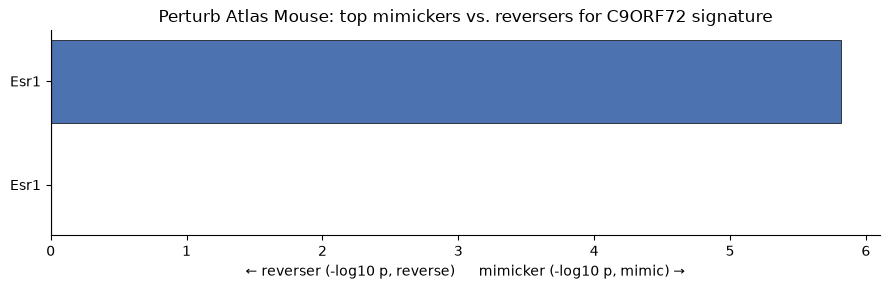

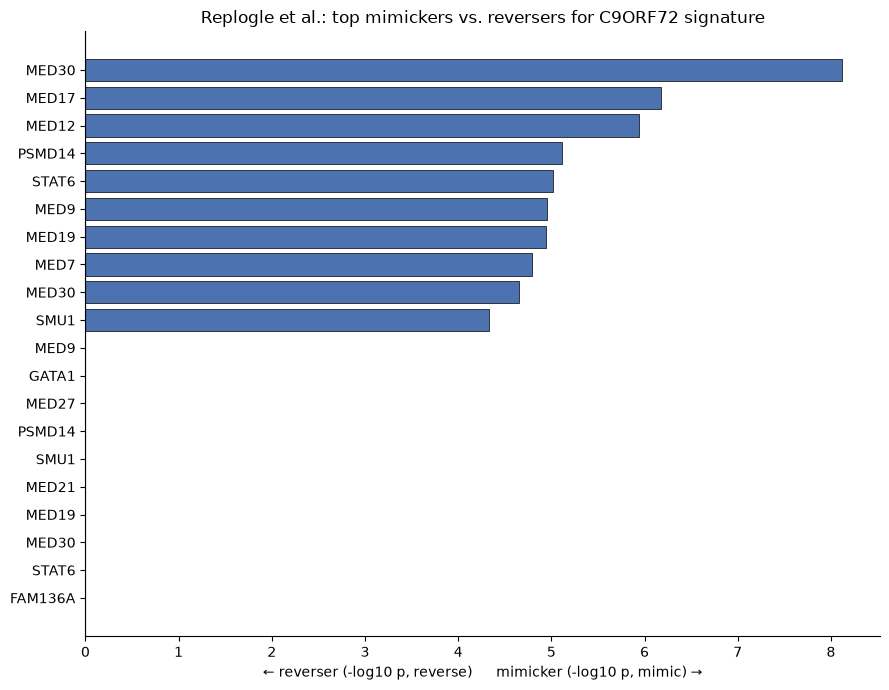

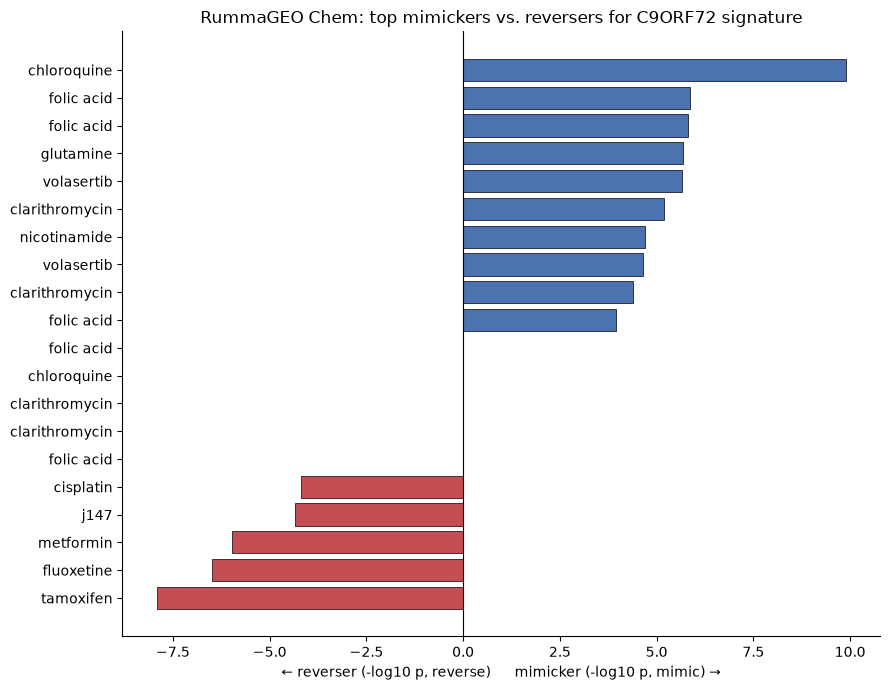

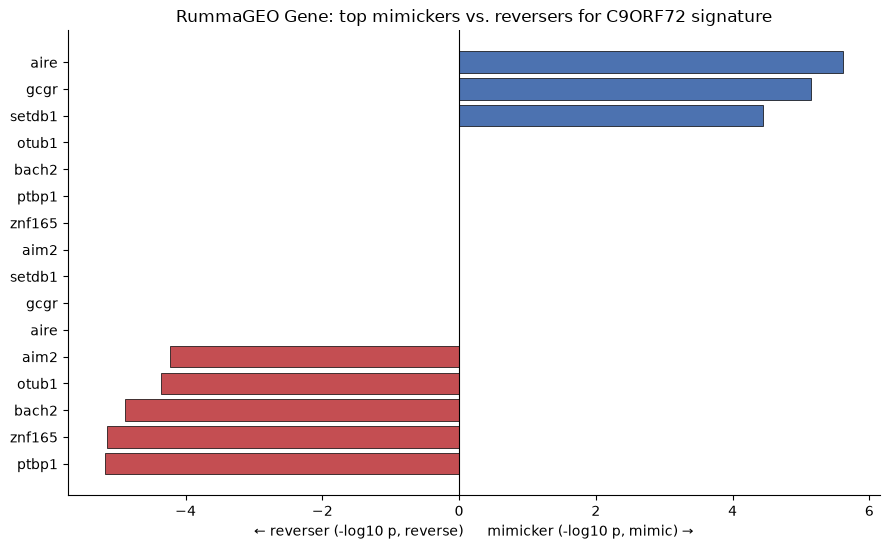

In [22]:
def make_perturbseqr_diverging_chart(library, df_mimic, df_reverse, top_n=10):
    """Diverging bar chart for one Perturb-Seqr library: top reversers (red, negative,
    extending left) vs. top mimickers (blue, positive, extending right), mirroring the
    style of the ARCHS4 correlated-genes chart (Figure 1)."""
    mim = df_mimic[df_mimic["library"] == library].sort_values("pvalueMimic").head(top_n) if not df_mimic.empty else df_mimic
    rev = df_reverse[df_reverse["library"] == library].sort_values("pvalueReverse").head(top_n) if not df_reverse.empty else df_reverse

    if mim.empty and rev.empty:
        return False

    mim_scores = -np.log10(mim["pvalueMimic"].clip(lower=1e-300)) if not mim.empty else pd.Series(dtype=float)
    rev_scores = np.log10(rev["pvalueReverse"].clip(lower=1e-300)) if not rev.empty else pd.Series(dtype=float)  # already negative

    # Reversers: most significant (most negative) farthest from zero, so plot from the
    # strongest outward -- ascending score puts the most negative first (top of chart).
    rev_order = rev_scores.sort_values(ascending=True).index if not rev.empty else []
    mim_order = mim_scores.sort_values(ascending=True).index if not mim.empty else []

    labels = [rev.loc[i, "term"] for i in rev_order] + [mim.loc[i, "term"] for i in mim_order]
    scores = [rev_scores.loc[i] for i in rev_order] + [mim_scores.loc[i] for i in mim_order]
    colors = ["#C44E52"] * len(rev_order) + ["#4C72B0"] * len(mim_order)

    fig_h = max(3, 0.35 * len(labels))
    plt.figure(figsize=(9, fig_h))
    ax = plt.gca()
    ax.barh(range(len(labels)), scores, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("← reverser (-log10 p, reverse)      mimicker (-log10 p, mimic) →")
    ax.set_title(f"{library}: top mimickers vs. reversers for {EXAMPLE_GENE} signature")
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    plt.tight_layout()

    safe_name = library.lower().replace(" ", "_").replace("/", "_")
    plt.savefig(f"perturbseqr_{safe_name}_mimic_vs_reverse_bar.png", bbox_inches="tight")
    plt.show()
    return True


libraries = sorted(
    set(df_enrichment_mimic["library"].dropna().unique() if not df_enrichment_mimic.empty else [])
    | set(df_enrichment_reverse["library"].dropna().unique() if not df_enrichment_reverse.empty else [])
)

for library in libraries:
    make_perturbseqr_diverging_chart(library, df_enrichment_mimic, df_enrichment_reverse, top_n=10)

## Consensus results with drug/gene labels

The `perturbation_type` classification computed earlier already annotates `df_consensus_pair`.
Below is the same top-20 consensus mimicker view as Table 3, with that label included, plus a
count of how many consensus hits fall into each category.

In [23]:
top_classified = df_consensus_mimic.sort_values("pvalueMimic").head(20)
display(HTML("<b>Table 7. Top 20 consensus perturbations classified as drug or gene</b>"))
top_classified[["perturbation", "perturbation_type", "pvalueMimic", "pvalueReverse", "libraries"]]

,perturbation,perturbation_type,pvalueMimic,pvalueReverse,libraries
0,setdb1,gene,1,1,[RummaGEO Gene]
31,aire,gene,1,1,[RummaGEO Gene]
30,gcgr,gene,1,1,[RummaGEO Gene]
29,FAM136A,gene,1,1,[Replogle et al.]
28,folic acid,drug,1,1,[RummaGEO Chem]
27,MED19,gene,1,1,[Replogle et al.]
26,tamoxifen,drug,1,1,[RummaGEO Chem]
25,znf165,gene,1,1,[RummaGEO Gene]
24,STAT6,gene,1,1,[Replogle et al.]
23,clarithromycin,drug,1,1,[RummaGEO Chem]


**Table 7 legend.** Same top consensus perturbations as Table 3, with an added
`perturbation_type` column classifying each as a `drug`, `gene`, `drug+gene` (appears in both
kinds of libraries), or `unknown` (library name not recognized), based on which source
library/libraries it was found in.

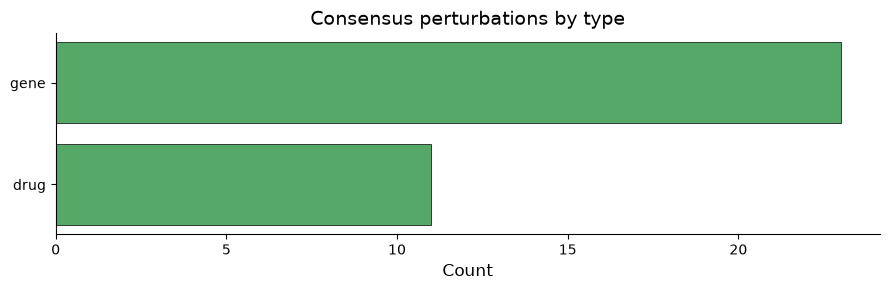

In [24]:
if "perturbation_type" in df_consensus_mimic.columns:
    type_counts = df_consensus_mimic["perturbation_type"].value_counts()
    make_bar_chart(
        type_counts.index, type_counts.values,
        title="Consensus perturbations by type",
        xlabel="Count",
        colors="#55A868",
    )
    plt.savefig("perturbseqr_type_counts_bar.png", bbox_inches="tight")
    plt.show()

**Figure 4.** Number of consensus perturbations classified as `drug`, `gene`, `drug+gene`, or
`unknown`.

## Download the results

Every table produced above can be saved as a CSV file. Running the cell below writes each table
to disk in the notebook's working directory and displays a clickable download link for each file
(the links work when this notebook is running in a local/hosted Jupyter server; in other
environments, the files can still be found in the working directory listed above each link).

In [ ]:
downloads = {
    f"{EXAMPLE_GENE}_archs4_positive_correlated_genes.csv": df_pos,
    f"{EXAMPLE_GENE}_archs4_negative_correlated_genes.csv": df_neg,
    f"{EXAMPLE_GENE}_perturbseqr_consensus_mimic_sorted.csv": df_consensus_mimic,
    f"{EXAMPLE_GENE}_perturbseqr_consensus_reverse_sorted.csv": df_consensus_reverse,
    f"{EXAMPLE_GENE}_perturbseqr_per_dataset_mimic_sorted.csv": df_enrichment_mimic,
    f"{EXAMPLE_GENE}_perturbseqr_per_dataset_reverse_sorted.csv": df_enrichment_reverse,
}

for filename, df in downloads.items():
    df.to_csv(filename, index=False)
    print(f"Saved {filename} ({len(df)} rows)")
    display(FileLink(filename))

## Summary

1. Pulled the top 100 positively/negatively correlated genes for **`EXAMPLE_GENE`** from
   [ARCHS4](https://archs4.org/), with a link to explore the gene interactively on the ARCHS4
   website.
2. Used those genes as an up/down signature to query [Perturb-Seqr's](https://perturbseqr.maayanlab.cloud/)
   Connectivity Map database.
3. Identified **mimicking** perturbations (same direction) and **reversing** perturbations
   (opposite direction) with two correctly-scoped queries (one sorted by mimic p-value, one by
   reverse p-value), visualized the top consensus hits as bar charts, drew a per-library
   diverging bar chart (reversers vs. mimickers) for the individual per-dataset results, and
   classified every hit as drug or gene perturbation.
4. Saved every results table to CSV with a one-click download link.

Try changing `EXAMPLE_GENE` at the top of the notebook to explore a different gene's correlated
signature and its associated regulators.